In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [75]:
df = pd.read_csv('../Data/Social_Media_Sentiment_Analysis_AI_Trends_2026.csv')
print(df.shape)
df.head()

(2200, 27)


,platform,post_id,user_id,username,user_verified,user_followers_count,user_location,post_text,language,hashtags,...,day_of_week,is_trending_topic,topic_category,sentiment_label,sentiment_score,emotion_label,toxicity_score,sarcasm_detected,spam_flag,data_source_url
0,YouTube,YO_100000,user_2679,rxckafna,True,375410,Germany,I don’t agree with this at all.,ur,"#news,#update",...,Wed,True,Technology,Positive,0.82,Sad,0.10,False,True,https://www.youtube.com
1,Reddit,RE_100001,user_3045,zjovqwps,True,346702,UK,Worst decision ever made.,fr,"#trending,#ai",...,Tue,False,Sports,Neutral,-0.02,Angry,0.67,True,True,https://www.reddit.com
2,YouTube,YO_100002,user_4598,rvufaigf,False,111487,Germany,This trend is getting out of hand.,de,"#news,#update",...,Fri,False,Finance,Positive,0.62,Neutral,0.43,False,False,https://www.youtube.com
3,Twitter,TW_100003,user_3504,qukbjznz,True,356674,Germany,Pretty neutral about the update.,en,"#trending,#ai",...,Thu,True,Finance,Neutral,0.14,Sad,0.97,True,True,https://www.twitter.com
4,YouTube,YO_100004,user_3646,ounaiayw,False,125551,USA,"Loved the explanation, very helpful.",es,"#trending,#ai",...,Sun,True,Technology,Neutral,-0.05,Fear,0.95,True,False,https://www.youtube.com


In [76]:
df.describe()

,user_followers_count,post_length,like_count,comment_count,share_count,engagement_score,sentiment_score,toxicity_score
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,251563.535455,31.432273,10009.355909,2475.158636,1471.210455,0.508855,0.010514,0.501041
std,143956.859442,3.764069,5885.532782,1425.979361,877.520927,0.293027,0.556477,0.284087
min,139.000000,25.000000,11.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,127377.750000,29.000000,4859.500000,1239.250000,700.750000,0.260000,-0.450000,0.260000
50%,246535.500000,31.000000,9758.500000,2437.500000,1458.000000,0.520000,0.010000,0.500000
75%,375852.000000,36.000000,15310.000000,3725.750000,2238.250000,0.760000,0.472500,0.740000
max,499778.000000,36.000000,20000.000000,5000.000000,3000.000000,1.000000,1.000000,1.000000


In [77]:
df.columns.tolist()

['platform',
 'post_id',
 'user_id',
 'username',
 'user_verified',
 'user_followers_count',
 'user_location',
 'post_text',
 'language',
 'hashtags',
 'mentions',
 'post_length',
 'like_count',
 'comment_count',
 'share_count',
 'engagement_score',
 'posted_datetime',
 'day_of_week',
 'is_trending_topic',
 'topic_category',
 'sentiment_label',
 'sentiment_score',
 'emotion_label',
 'toxicity_score',
 'sarcasm_detected',
 'spam_flag',
 'data_source_url']

In [78]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
platform,2200,3,YouTube,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,2200,2200,YO_100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,2200,1950,user_2888,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
username,2200,2200,rxckafna,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_verified,2200,2,True,1131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_followers_count,2200.0,NaN,NaN,NaN,251563.535455,143956.859442,139.0,127377.75,246535.5,375852.0,499778.0
user_location,2200,6,Canada,384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_text,2200,10,I’m confused about the announcement.,243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,2200,5,es,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hashtags,2200,2,"#news,#update",1140,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Eda

In [79]:
df.isnull().sum().sort_values(ascending=False)

mentions                1328
platform                   0
share_count                0
spam_flag                  0
sarcasm_detected           0
toxicity_score             0
emotion_label              0
sentiment_score            0
sentiment_label            0
topic_category             0
is_trending_topic          0
day_of_week                0
posted_datetime            0
engagement_score           0
comment_count              0
post_id                    0
like_count                 0
post_length                0
hashtags                   0
language                   0
post_text                  0
user_location              0
user_followers_count       0
user_verified              0
username                   0
user_id                    0
data_source_url            0
dtype: int64

In [80]:
df.duplicated().sum()

np.int64(0)

## ```Target Distribution```

In [81]:
df['sentiment_label'].value_counts()

sentiment_label
Neutral     748
Positive    737
Negative    715
Name: count, dtype: int64

In [82]:
df['sentiment_label'].value_counts(normalize=True) * 100

sentiment_label
Neutral     34.0
Positive    33.5
Negative    32.5
Name: proportion, dtype: float64

## ```Visualization```

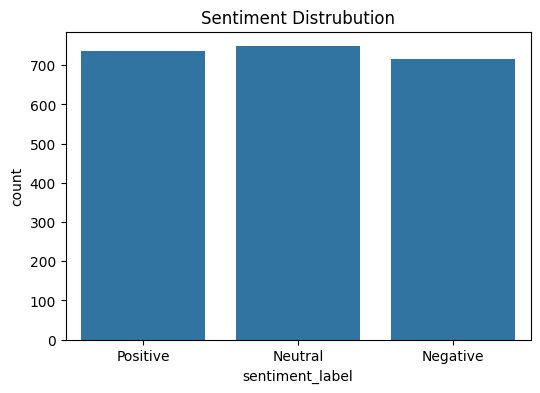

In [83]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x= "sentiment_label")
plt.title("Sentiment Distrubution")
plt.show()

### ```Univariate Analysis (Categorical Features)```

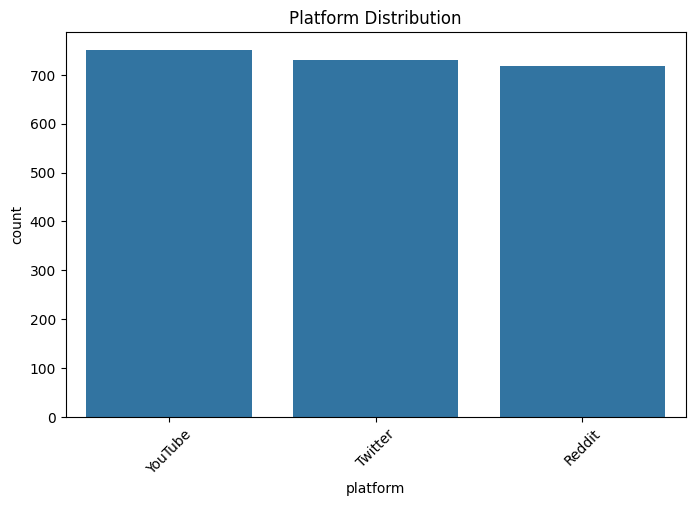

In [84]:
### Platform Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='platform', order=df['platform'].value_counts().index)
plt.title("Platform Distribution")
plt.xticks(rotation=45)
plt.show()

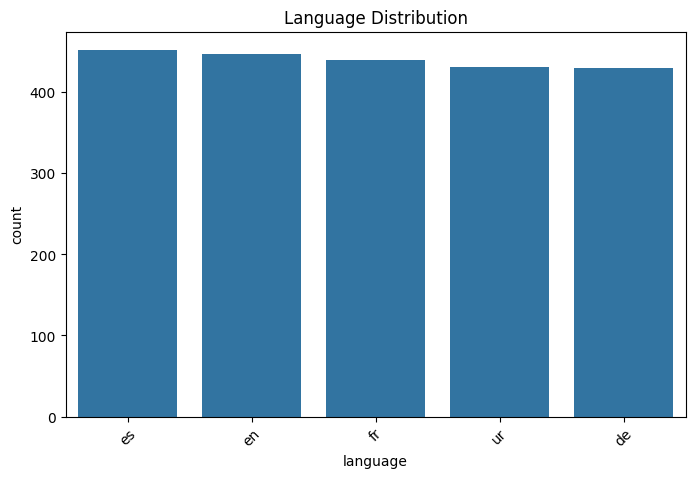

In [85]:

## Language Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='language', order=df['language'].value_counts().index)
plt.title("Language Distribution")
plt.xticks(rotation=45)
plt.show()

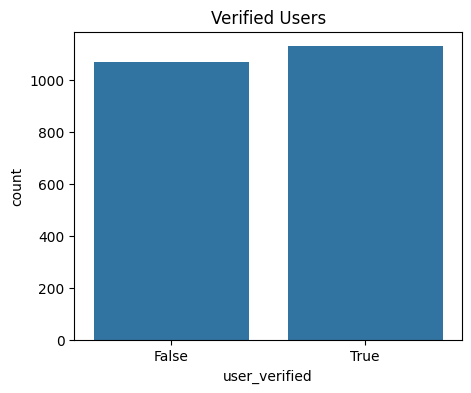

In [86]:
## User Verification
plt.figure(figsize=(5,4))
sns.countplot(data=df,x = 'user_verified')
plt.title("Verified Users")
plt.show()

### ``` Univariate Analysis (Numerical Features)```

In [87]:
num_cols = [
    'user_followers_count',
    'post_length',
    'like_count',
    'comment_count',
    'share_count',
    'engagement_score',
    'sentiment_score',
    'toxicity_score'
]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
user_followers_count,2200.0,251563.535455,143956.859442,139.0,127377.75,246535.50,375852.0000,499778.0
post_length,2200.0,31.432273,3.764069,25.0,29.00,31.00,36.0000,36.0
like_count,2200.0,10009.355909,5885.532782,11.0,4859.50,9758.50,15310.0000,20000.0
comment_count,2200.0,2475.158636,1425.979361,0.0,1239.25,2437.50,3725.7500,5000.0
share_count,2200.0,1471.210455,877.520927,0.0,700.75,1458.00,2238.2500,3000.0
engagement_score,2200.0,0.508855,0.293027,0.0,0.26,0.52,0.7600,1.0
sentiment_score,2200.0,0.010514,0.556477,-1.0,-0.45,0.01,0.4725,1.0
toxicity_score,2200.0,0.501041,0.284087,0.0,0.26,0.50,0.7400,1.0


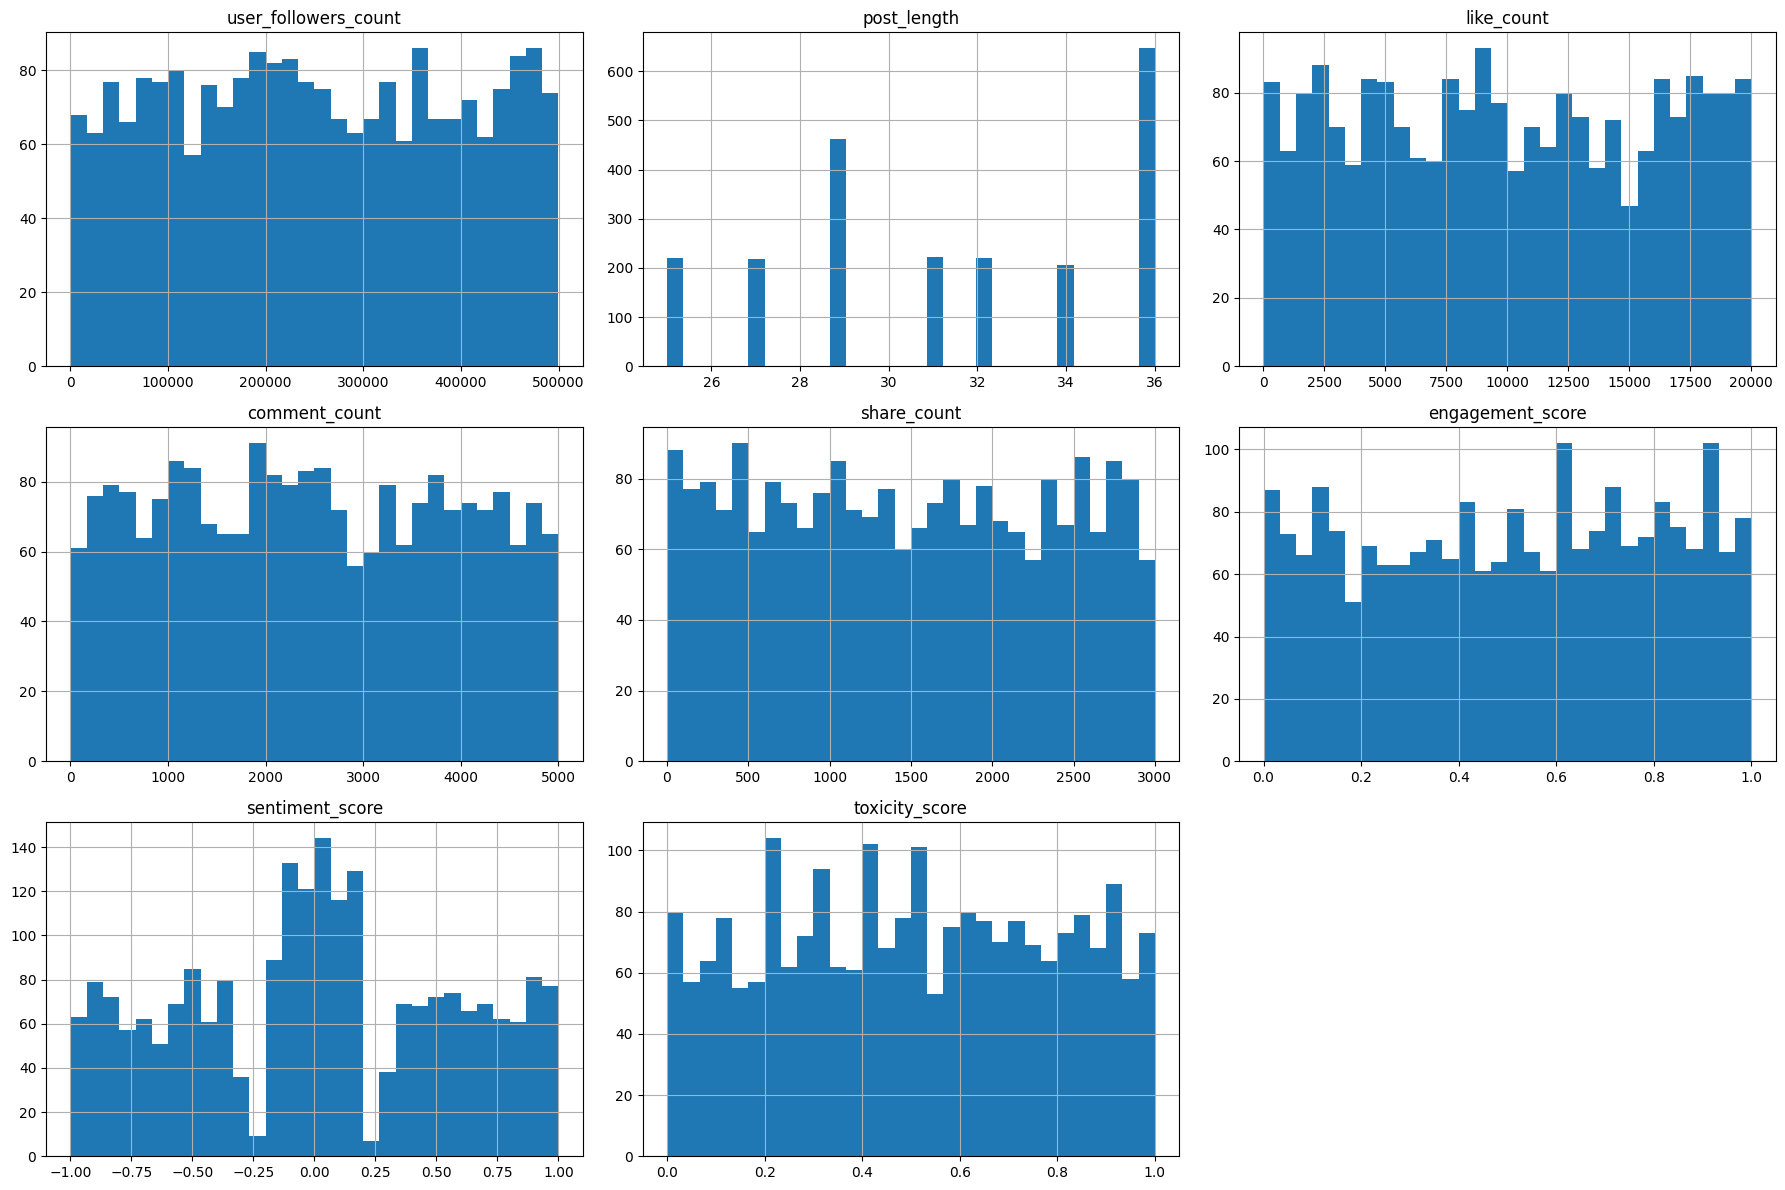

In [88]:
df[num_cols].hist(figsize=(18,12), bins=30)
plt.tight_layout()
plt.show()

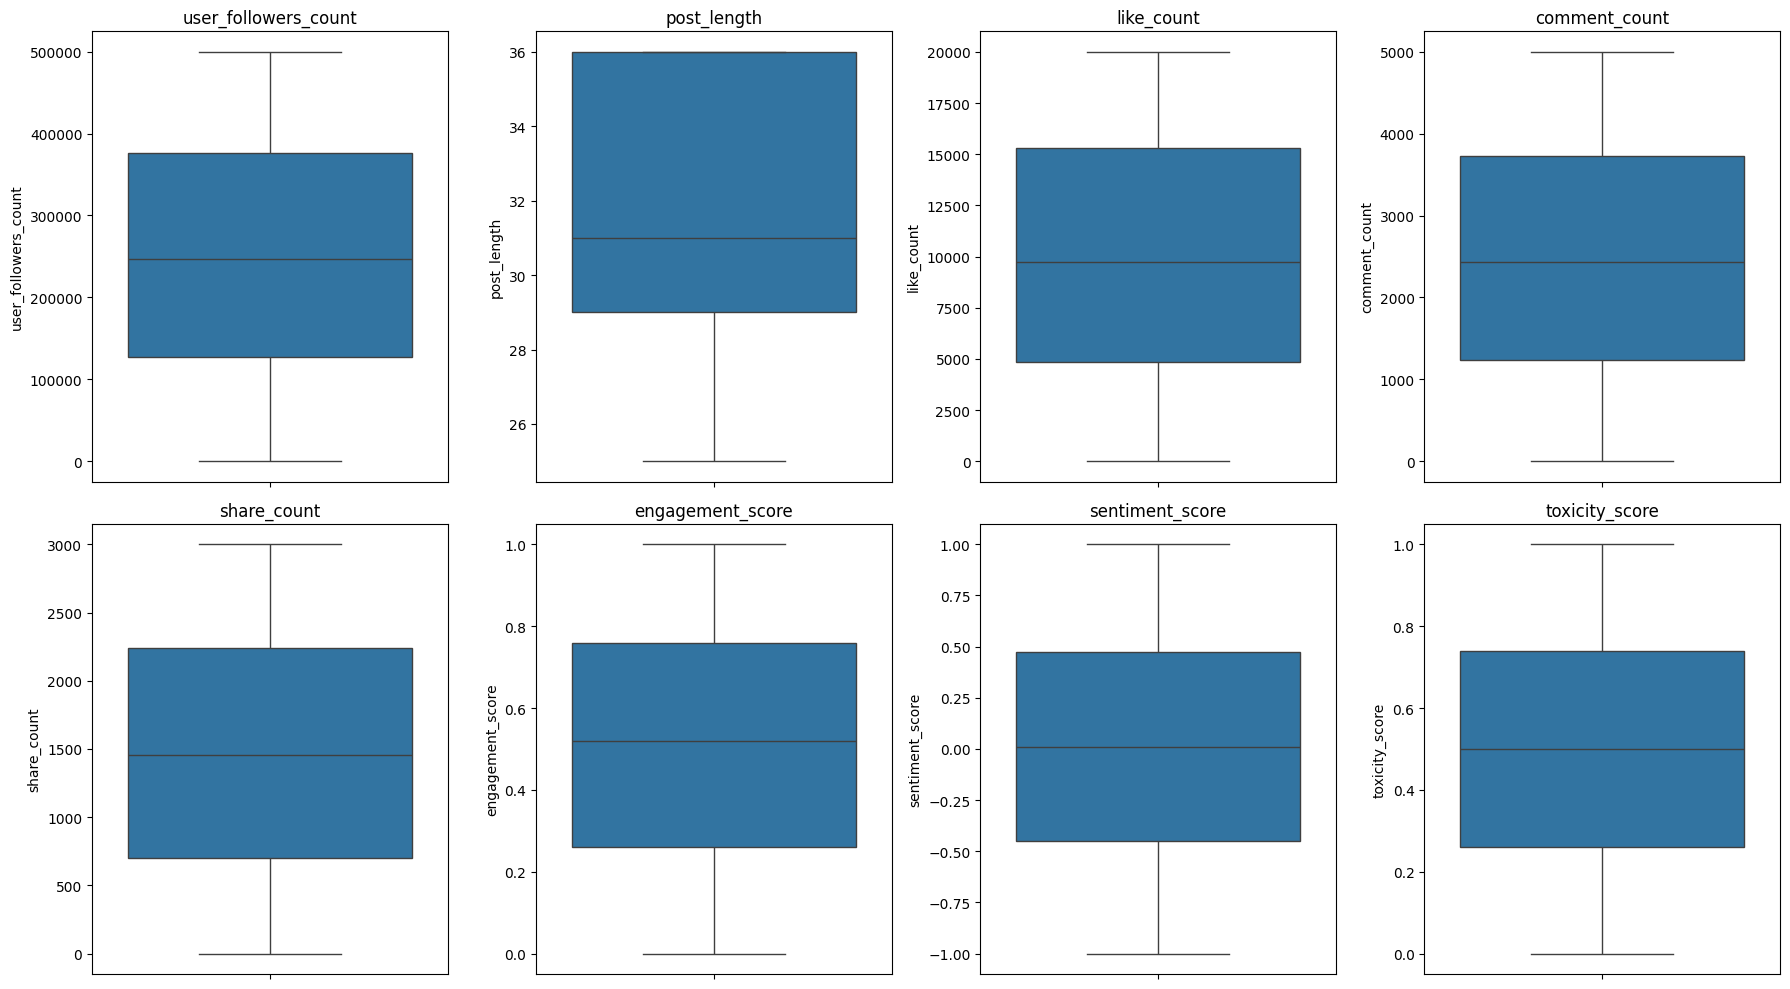

In [89]:
## box plots
plt.figure(figsize=(18,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### ```Step (EDA Part-3)```

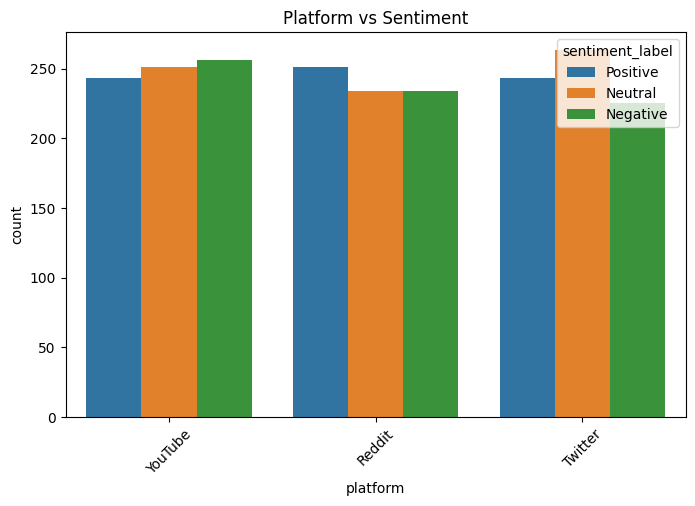

In [90]:
# 1. Platform vs Sentimen
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='platform', hue='sentiment_label')
plt.title("Platform vs Sentiment")
plt.xticks(rotation=45)
plt.show()

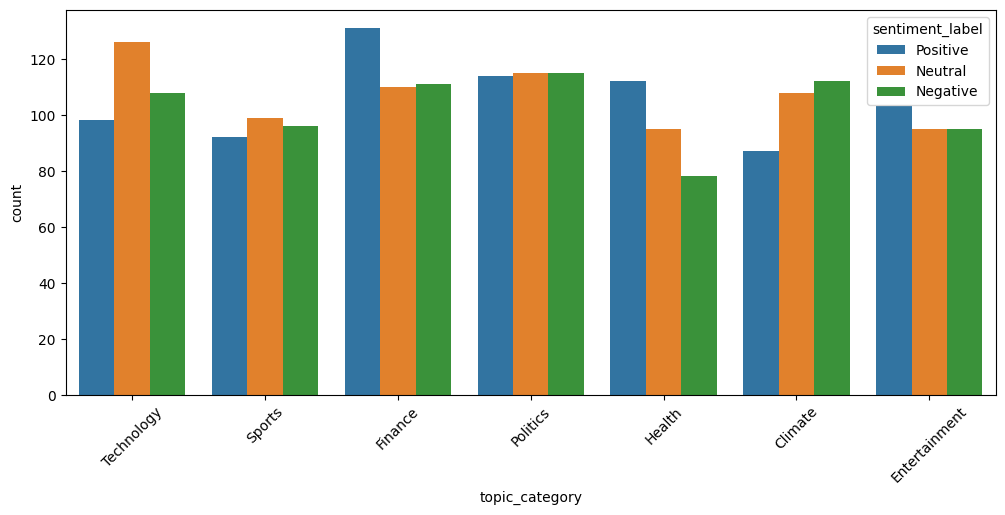

In [91]:
## Topic Category vs Sentiment
plt.figure(figsize=(12,5))
sns.countplot(data=df,
              x='topic_category',
              hue='sentiment_label')

plt.xticks(rotation=45)
plt.show()

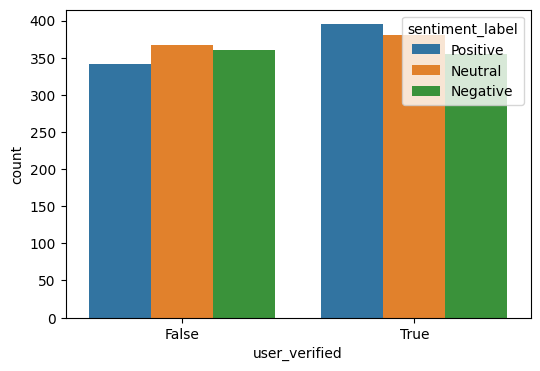

In [92]:
## verified users vs sentiment 
plt.figure(figsize=(6,4))
sns.countplot(data=df,
              x='user_verified',
              hue='sentiment_label')

plt.show()

In [93]:
## Remove unecesaryy column
drop_cols = [
    'post_id',
    'user_id',
    'username',
    'data_source_url',
    'sentiment_score',
    'emotion_label',
    'toxicity_score'
]

df = df.drop(columns=drop_cols)

In [94]:
df.columns.tolist()

['platform',
 'user_verified',
 'user_followers_count',
 'user_location',
 'post_text',
 'language',
 'hashtags',
 'mentions',
 'post_length',
 'like_count',
 'comment_count',
 'share_count',
 'engagement_score',
 'posted_datetime',
 'day_of_week',
 'is_trending_topic',
 'topic_category',
 'sentiment_label',
 'sarcasm_detected',
 'spam_flag']

## 🚀 Step 5 : NLP Data Cleaning

In [95]:
df['clean_text'] = df['post_text']

In [96]:
## change into lower case
df['clean_text'] = df['clean_text'].str.lower()

In [97]:
df['clean_text']

0            i don’t agree with this at all.
1                  worst decision ever made.
2         this trend is getting out of hand.
3           pretty neutral about the update.
4       loved the explanation, very helpful.
                        ...                 
2195             this is absolutely amazing!
2196    i’m confused about the announcement.
2197           not bad, but could be better.
2198    i’m confused about the announcement.
2199             this is absolutely amazing!
Name: clean_text, Length: 2200, dtype: object

In [98]:
## Remove URLs form post_text
import re

df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', x)
)

In [99]:
##Remove Punctuation
import string

df['clean_text'] = df['clean_text'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

In [100]:
df['clean_text']

0            i don’t agree with this at all
1                  worst decision ever made
2         this trend is getting out of hand
3           pretty neutral about the update
4        loved the explanation very helpful
                       ...                 
2195             this is absolutely amazing
2196    i’m confused about the announcement
2197            not bad but could be better
2198    i’m confused about the announcement
2199             this is absolutely amazing
Name: clean_text, Length: 2200, dtype: object

In [101]:
## remove Punctuation 
import re

df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r"[^\w\s]", "", x)
)

In [102]:
df[['post_text', 'clean_text']].head(10)

,post_text,clean_text
0,I don’t agree with this at all.,i dont agree with this at all
1,Worst decision ever made.,worst decision ever made
2,This trend is getting out of hand.,this trend is getting out of hand
3,Pretty neutral about the update.,pretty neutral about the update
4,"Loved the explanation, very helpful.",loved the explanation very helpful
5,I’m confused about the announcement.,im confused about the announcement
6,People need to talk about this more.,people need to talk about this more
7,"Not bad, but could be better.",not bad but could be better
8,I don’t agree with this at all.,i dont agree with this at all
9,I don’t agree with this at all.,i dont agree with this at all


In [103]:
## Remove Extra Spaces
df['clean_text'] = df['clean_text'].str.replace(r"\s+", " ", regex=True).str.strip()

In [104]:
df['clean_text']

0            i dont agree with this at all
1                 worst decision ever made
2        this trend is getting out of hand
3          pretty neutral about the update
4       loved the explanation very helpful
                       ...                
2195            this is absolutely amazing
2196    im confused about the announcement
2197           not bad but could be better
2198    im confused about the announcement
2199            this is absolutely amazing
Name: clean_text, Length: 2200, dtype: object

## ```PERFROM Lemmatization:```

```Lemmatization is a text-processing technique in Natural Language Processing (NLP) that reduces words to their canonical dictionary form, known as a lemma. Unlike simpler methods, it analyzes grammar and context to ensure the output is a valid, meaningful word```

In [105]:
import nltk
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\manis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\manis\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\manis\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### ```Tokenization:```

```Tokenization is the process of breaking text into smaller pieces called tokens (words, subwords, or characters) so that a machine learning model can understand and process the text.```

Sentence:
"I love Machine Learning"

After Tokenization:
["I", "love", "Machine", "Learning"]

In [106]:
from nltk.tokenize import word_tokenize
df['tokens'] = df['clean_text'].apply(word_tokenize)

In [107]:
df[['clean_text', 'tokens']].head(5)

,clean_text,tokens
0,i dont agree with this at all,"[i, dont, agree, with, this, at, all]"
1,worst decision ever made,"[worst, decision, ever, made]"
2,this trend is getting out of hand,"[this, trend, is, getting, out, of, hand]"
3,pretty neutral about the update,"[pretty, neutral, about, the, update]"
4,loved the explanation very helpful,"[loved, the, explanation, very, helpful]"


### ```Remove Stop words as Samartly```

In [108]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Important negation words preserve karenge
keep_words = {'not', 'no', 'nor'}

stop_words = stop_words - keep_words

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [109]:
df[['clean_text', 'tokens']].head(10)

,clean_text,tokens
0,i dont agree with this at all,"[dont, agree]"
1,worst decision ever made,"[worst, decision, ever, made]"
2,this trend is getting out of hand,"[trend, getting, hand]"
3,pretty neutral about the update,"[pretty, neutral, update]"
4,loved the explanation very helpful,"[loved, explanation, helpful]"
5,im confused about the announcement,"[im, confused, announcement]"
6,people need to talk about this more,"[people, need, talk]"
7,not bad but could be better,"[not, bad, could, better]"
8,i dont agree with this at all,"[dont, agree]"
9,i dont agree with this at all,"[dont, agree]"


### ```Lemmatization```

In [110]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(
    lambda  words:[lemmatizer.lemmatize(word) for word in words]
)

In [112]:
df[['clean_text','tokens']]

,clean_text,tokens
0,i dont agree with this at all,"[dont, agree]"
1,worst decision ever made,"[worst, decision, ever, made]"
2,this trend is getting out of hand,"[trend, getting, hand]"
3,pretty neutral about the update,"[pretty, neutral, update]"
4,loved the explanation very helpful,"[loved, explanation, helpful]"
...,...,...
2195,this is absolutely amazing,"[absolutely, amazing]"
2196,im confused about the announcement,"[im, confused, announcement]"
2197,not bad but could be better,"[not, bad, could, better]"
2198,im confused about the announcement,"[im, confused, announcement]"


## 6: ``Text → Numbers``